In [1]:
import anndata as ad
import h5py
import pandas as pd
import numpy as np
import umap

In [2]:
#h5ad_file = "BG/Human_HMBA_basalganglia_AIT_pre-print.h5ad"
#h5ad_file = "jgf/integrated_data.h5ad"
h5ad_file = "e4ddac12-f48f-4455-8e8d-c2a48a683437.h5ad"

In [3]:
# for weird file
f = h5py.File(h5ad_file, "r")
print(list(f.keys()))  # top-level groups
#print(list(f["layers"].keys()))  # what layers are present
#print(list(f["obsm"].keys()))    # embeddings stored
#print(list(f["obs"].keys()))    # embeddings stored
#print(list(f["uns"].keys()))     # unstructured metadata


['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']


## Basic info

In [3]:
# for typical file
#adata = ad.read_h5ad(h5ad_file, backed="r")
adata = ad.read_h5ad(h5ad_file)

In [4]:
adata

AnnData object with n_obs × n_vars = 129495 × 29322
    obs: 'Class', 'CrossArea_subclass', 'CrossArea_cluster', 'WithinArea_subclass', 'WithinArea_cluster', 'Source', 'Layer', 'Location', 'Region', 'Subregion', 'nCount_RNA', 'nFeature_RNA', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'is_primary_data', 'donor_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'is_primary_data', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP'

In [5]:
total_counts = adata.raw.X.sum(axis=1).A1   # .A1 flattens to 1D
total_counts

array([ 5473.,  9531., 10928., ..., 17273.,  8339., 14889.], dtype=float32)

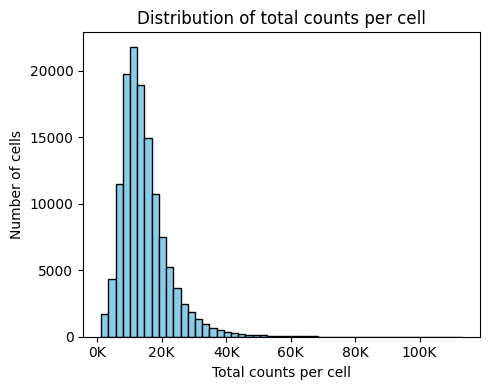

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(5,4))
plt.hist(total_counts, bins=50, color='skyblue', edgecolor='k')

# X-axis in thousands/millions
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K' if x < 1e6 else f'{x/1e6:.1f}M'))

plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of total counts per cell")
plt.tight_layout()
plt.show()

In [7]:
median_counts = np.median(total_counts)
print("Median total counts per cell:", median_counts)

Median total counts per cell: 13044.0


In [5]:
from scipy.sparse import coo_matrix

# Convert raw.X to COO format to get row/col indices of nonzeros
raw_coo = adata.raw.X.tocoo()

rows = raw_coo.row      # cell indices
cols = raw_coo.col      # gene indices
raw_vals = raw_coo.data # values in raw

In [6]:
# For sparse matrices, index and convert to 1D
x_vals = adata.X[rows, cols].A1  # .A1 = flatten to 1D array

In [10]:
len(raw_vals), len(x_vals), np.count_nonzero(raw_vals)

(592337817, 592337817, 592337817)

In [20]:
n_total = len(raw_vals)

# number to sample
n_sample = 10_000_000

# random indices
sample_idx = np.random.choice(n_total, size=n_sample)

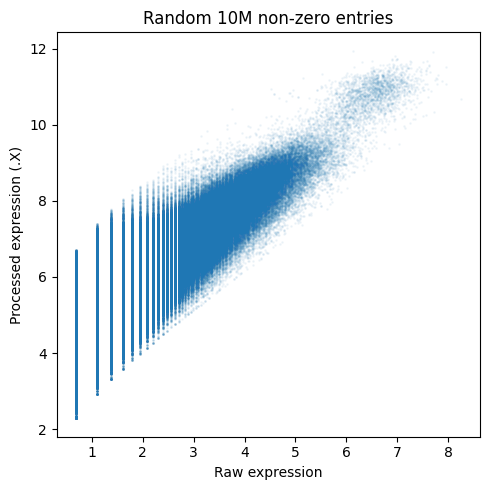

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(np.log1p(raw_vals[sample_idx]), x_vals[sample_idx], s=1, alpha=0.05)
plt.xlabel("Raw expression")
plt.ylabel("Processed expression (.X)")
plt.title("Random 10M non-zero entries")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.scatter(np.log1p(raw_vals), x_vals, s=5, alpha=0.5)

plt.xlabel("log1p(count)\nlog1p(.raw.X)")
plt.ylabel("author further downstream post-processed \n.X")
plt.title(f"all cells")

plt.tight_layout()
plt.show()

In [46]:
cell_idx =[0,3, 10, 100]
# X (processed)
x_cell = adata.X[cell_idx, :]

# raw
raw_cell = adata.raw.X[cell_idx, :]

x_cell = x_cell.toarray().ravel()
raw_cell = raw_cell.toarray().ravel()

both_zero = np.sum((x_cell == 0) & (raw_cell == 0))
x_only    = np.sum((x_cell > 0) & (raw_cell == 0))   # (>0, 0)
raw_only  = np.sum((x_cell == 0) & (raw_cell > 0))   # (0, >0)
both_pos  = np.sum((x_cell > 0) & (raw_cell > 0))

print(f"(0, 0)   : {both_zero}")
print(f"(>0, 0)  : {x_only}")
print(f"(0, >0)  : {raw_only}")
print(f"(>0, >0) : {both_pos}")

(0, 0)   : 102242
(>0, 0)  : 0
(0, >0)  : 0
(>0, >0) : 15046


In [47]:
mask = (x_cell != 0) | (raw_cell != 0)
x_cell_nz = x_cell[mask]
raw_cell_nz = raw_cell[mask]
len(x_cell_nz)

15046

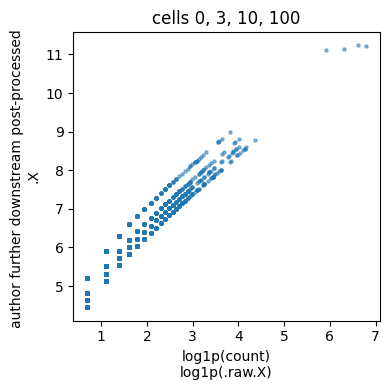

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.scatter(np.log1p(raw_cell_nz), x_cell_nz, s=5, alpha=0.5)

plt.xlabel("log1p(count)\nlog1p(.raw.X)")
plt.ylabel("author further downstream post-processed \n.X")
plt.title(f"cells {', '.join(map(str, cell_idx))}")


plt.tight_layout()
plt.show()

In [11]:
new_adata = ad.AnnData(
    X=adata.raw._X.copy(),     # use the modified raw
    obs=adata.obs.copy(),      # keep cell metadata
    var=adata.var.copy()       # keep gene metadata
)
import scanpy as sc
# Normalizing to median total counts
sc.pp.normalize_total(new_adata, target_sum = 1_000_000)
# Logarithmize the data
sc.pp.log1p(new_adata)

In [12]:
# For sparse matrices, index and convert to 1D
lognorm1M_vals = new_adata.X[rows, cols].A1  # .A1 = flatten to 1D array

In [13]:
len(lognorm1M_vals)

592337817

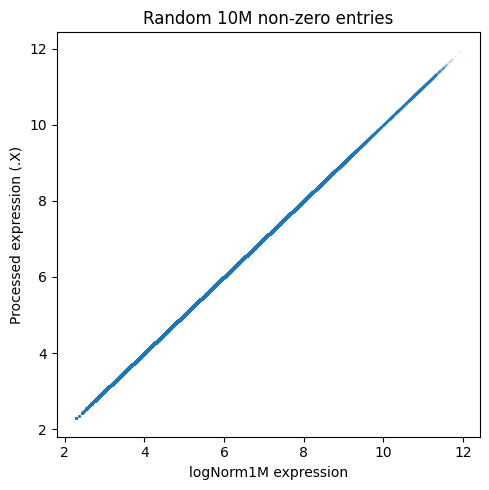

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(lognorm1M_vals[sample_idx], x_vals[sample_idx], s=1, alpha=0.05)
plt.xlabel("logNorm1M expression")
plt.ylabel("Processed expression (.X)")
plt.title("Random 10M non-zero entries")
plt.tight_layout()
plt.show()

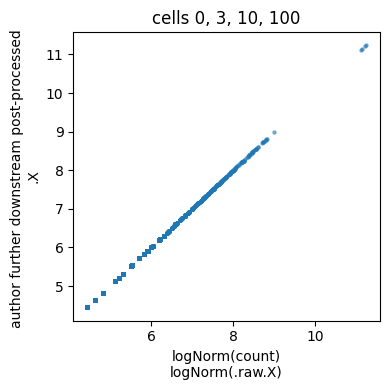

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.scatter(lognorm_cell, x_cell_nz, s=5, alpha=0.5)

plt.xlabel("logNorm(count)\nlogNorm(.raw.X)")
plt.ylabel("author further downstream post-processed \n.X")
plt.title(f"cells {', '.join(map(str, cell_idx))}")

plt.tight_layout()
plt.show()

In [8]:
adata.uns

{'batch_condition': array(['donor_id'], dtype=object),
 'citation': 'Publication: https://doi.org/10.1126/science.adf6812 Dataset Version: https://datasets.cellxgene.cziscience.com/cb095b8e-acc5-4aa1-b3e8-eebdca374cb7.h5ad curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/d17249d2-0e6e-4500-abb8-e6c93fa1ac6f',
 'default_embedding': 'X_UMAP',
 'is_primary_data': np.False_,
 'organism': 'Homo sapiens',
 'organism_ontology_term_id': 'NCBITaxon:9606',
 'schema_reference': 'https://github.com/chanzuckerberg/single-cell-curation/blob/main/schema/7.0.0/schema.md',
 'schema_version': '7.0.0',
 'title': 'Supercluster: CGE-derived interneurons'}

In [7]:
adata.var

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000233576,False,HTR3C2P,NCBITaxon:9606,gene,1057,unprocessed_pseudogene
ENSG00000121410,False,A1BG,NCBITaxon:9606,gene,2301,protein_coding
ENSG00000268895,False,A1BG-AS1,NCBITaxon:9606,gene,1667,lncRNA
ENSG00000148584,False,A1CF,NCBITaxon:9606,gene,2211,protein_coding
ENSG00000175899,False,A2M,NCBITaxon:9606,gene,590,protein_coding
...,...,...,...,...,...,...
ENSG00000203995,False,ZYG11A,NCBITaxon:9606,gene,4193,protein_coding
ENSG00000162378,False,ZYG11B,NCBITaxon:9606,gene,5218,protein_coding
ENSG00000159840,False,ZYX,NCBITaxon:9606,gene,814,protein_coding
ENSG00000074755,False,ZZEF1,NCBITaxon:9606,gene,2667,protein_coding


In [5]:
adata_sub = adata[adata.obs["file_name"] == "CHD8_GM.h5ad"]
adata_sub.write("tmpdata/CHD8_GM.h5ad")

In [8]:
#print(np.unique(adata.obs.file_name))
adata.obs.groupby("file_name").size()

/tmp/ipykernel_3206/3514113725.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("file_name").size()


file_name
CHD8_GM.h5ad                             28950
CHD8_H1.h5ad                             43589
CHD8_HUES.h5ad                          106309
PTEN.h5ad                                36786
SSPG000FRD.h5ad                         215928
SSPG000FRE.h5ad                          35240
SSPG000FRF.h5ad                          26549
SSPG000FRG.h5ad                          28388
SSPG000FRH.h5ad                          38097
SUV_Mito29.h5ad                          30733
SUV_Mito210_1m.h5ad                      57941
SUV_Mito210_3m.h5ad                      65887
SUV_PGP.h5ad                             37510
Wells_village_ngn2.h5ad                   9662
autism_velmeshev_dataset.h5ad           104559
clean.Dev_metaatlas_integrated.h5ad     599211
hnoca_dataset.h5ad                     1770578
dtype: int64

In [8]:
adata.obs.groupby([ "file_name", "tissue_type"]).size()

/tmp/ipykernel_6624/2388857767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby([ "file_name", "tissue_type"]).size()


file_name                            tissue_type   
CHD8_GM.h5ad                         NGN2-derived            0
                                     Organoid            28950
                                     Primary tissue          0
CHD8_H1.h5ad                         NGN2-derived            0
                                     Organoid            43589
                                     Primary tissue          0
CHD8_HUES.h5ad                       NGN2-derived            0
                                     Organoid           106309
                                     Primary tissue          0
PTEN.h5ad                            NGN2-derived            0
                                     Organoid            36786
                                     Primary tissue          0
SSPG000FRD.h5ad                      NGN2-derived       215928
                                     Organoid                0
                                     Primary tissue          0
SSP

In [17]:
print(np.unique(adata.obs.Neighborhood))
print(np.unique(adata.obs.Class))
print(np.unique(adata.obs.Subclass))
print(np.unique(adata.obs.Group))

['Glut Sero Dopa' 'Nonneuron' 'Subpallium GABA' 'Subpallium GABA-Glut']
['Astro-Epen' 'CN CGE GABA' 'CN GABA-Glut' 'CN LGE GABA' 'CN MGE GABA'
 'Cx GABA' 'F M GABA' 'F M Glut' 'Immune' 'M Dopa' 'OPC-Oligo' 'Vascular']
['ACx MEIS2 GABA' 'Astrocyte' 'CN Cholinergic GABA' 'CN GABA-Glut'
 'CN LAMP5-CXCL14 GABA' 'CN LAMP5-LHX6 GABA' 'CN LHX8 GABA'
 'CN MEIS2 GABA' 'CN ONECUT1 GABA' 'CN ST18 GABA' 'CN VIP GABA' 'COP'
 'Endo' 'Ependymal' 'F GABA' 'F Glut' 'F M GATA3 GABA' 'F M Glut'
 'Lymphocyte' 'M Dopa' 'Macrophage' 'Microglia' 'Monocyte' 'OPC'
 'OT Granular GABA' 'Oligodendrocyte' 'Pericyte' 'SMC' 'SN PAX7 GABA'
 'STR D1 MSN' 'STR D2 MSN' 'STR Hybrid MSN' 'STR RSPO2 GABA'
 'STR SST GABA' 'STR SST-CHODL GABA' 'VLMC']
['AMY-SLEA-BNST D1 GABA' 'AMY-SLEA-BNST GABA' 'Astrocyte' 'B cells' 'BAM'
 'BF SKOR1 Glut' 'COP' 'Endo' 'Ependymal' 'GPe MEIS2-SOX6 GABA'
 'GPe SOX6-CTXND1 GABA' 'GPe-NDB-SI LHX6-LHX8-GBX1 GABA' 'GPi Core'
 'GPi Shell' 'GPin-BF Cholinergic GABA' 'ImAstro' 'ImOligo'
 'LAMP5-CXCL

In [43]:
adata.obs[adata.obs.Group == "Astrocyte"]

,Neighborhood,Class,Subclass,Group,Cluster,cluster_id,cell_type_ontology_term,load_id,donor_id,assay,...,color_class,accession_neighborhood,CL:ID_neighborhood,tokens_neighborhood,display_order_neighborhood,color_hex_neighborhood,color_neighborhood,cell_barcode,barcoded_cell_sample_label,alignment_job_database
AAACAGCCATTGTGGC-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Human-14,CL:0000003,2362_A05,H24.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,AAACAGCCATTGTGGC,2362_A05,AIBS
AAACATGCAGTAGGAT-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-159,Human-159,CL:0000003,2362_A05,H24.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,AAACATGCAGTAGGAT,2362_A05,AIBS
AAACCGCGTTGACTTC-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Human-14,CL:0000003,2362_A05,H24.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,AAACCGCGTTGACTTC,2362_A05,AIBS
AAAGCCGCACCTAATG-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-28,Human-28,CL:0000003,2362_A05,H24.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,AAAGCCGCACCTAATG,2362_A05,AIBS
AAAGCGGGTCATCATC-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-160,Human-160,CL:0000003,2362_A05,H24.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,AAAGCGGGTCATCATC,2362_A05,AIBS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGCTTCCTACCTA-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Human-14,CL:0000003,2016_B03,H23.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,TTTAGCTTCCTACCTA,2016_B03,AIBS
TTTAGGATCACTAGGT-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Human-14,CL:0000003,2016_B03,H23.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,TTTAGGATCACTAGGT,2016_B03,AIBS
TTTATGGAGTTGTCCC-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Human-14,CL:0000003,2016_B03,H23.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,TTTATGGAGTTGTCCC,2016_B03,AIBS
TTTGACCGTGCTTTAC-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Human-14,CL:0000003,2016_B03,H23.30.001,10x multiome,...,NaN,CS20250428_NEIGH_0001,CL:0000000,Nonneuron,1,#f2ca7d,NaN,TTTGACCGTGCTTTAC,2016_B03,AIBS


In [40]:
for column in adata.obs.columns:
    if column.startswith("atac_") or column.startswith("gex_") or column.startswith("color_") \
        or column.startswith("display_") or column.startswith("Cluster") or column.startswith("cluster_") \
        or column.endswith("_id") or column.startswith("accession_group") or column.startswith("CL:ID_") :
        continue
    print(column), print(np.unique(adata.obs[column].astype(str)))

Neighborhood
['Glut Sero Dopa' 'Nonneuron' 'Subpallium GABA' 'Subpallium GABA-Glut']
Class
['Astro-Epen' 'CN CGE GABA' 'CN GABA-Glut' 'CN LGE GABA' 'CN MGE GABA'
 'Cx GABA' 'F M GABA' 'F M Glut' 'Immune' 'M Dopa' 'OPC-Oligo' 'Vascular']
Subclass
['ACx MEIS2 GABA' 'Astrocyte' 'CN Cholinergic GABA' 'CN GABA-Glut'
 'CN LAMP5-CXCL14 GABA' 'CN LAMP5-LHX6 GABA' 'CN LHX8 GABA'
 'CN MEIS2 GABA' 'CN ONECUT1 GABA' 'CN ST18 GABA' 'CN VIP GABA' 'COP'
 'Endo' 'Ependymal' 'F GABA' 'F Glut' 'F M GATA3 GABA' 'F M Glut'
 'Lymphocyte' 'M Dopa' 'Macrophage' 'Microglia' 'Monocyte' 'OPC'
 'OT Granular GABA' 'Oligodendrocyte' 'Pericyte' 'SMC' 'SN PAX7 GABA'
 'STR D1 MSN' 'STR D2 MSN' 'STR Hybrid MSN' 'STR RSPO2 GABA'
 'STR SST GABA' 'STR SST-CHODL GABA' 'VLMC']
Group
['AMY-SLEA-BNST D1 GABA' 'AMY-SLEA-BNST GABA' 'Astrocyte' 'B cells' 'BAM'
 'BF SKOR1 Glut' 'COP' 'Endo' 'Ependymal' 'GPe MEIS2-SOX6 GABA'
 'GPe SOX6-CTXND1 GABA' 'GPe-NDB-SI LHX6-LHX8-GBX1 GABA' 'GPi Core'
 'GPi Shell' 'GPin-BF Cholinergic GABA

In [46]:
for column in adata.obs.columns:
    print (column)


assay_ontology_term_id
cell_type_ontology_term_id
development_stage_ontology_term_id
disease_ontology_term_id
self_reported_ethnicity_ontology_term_id
organism_ontology_term_id
sex_ontology_term_id
tissue_ontology_term_id
is_primary_data
Class
Subclass
Supertype
Age at death
donor_id
suspension_type
Number of UMIs
Genes detected
Fraction mitochrondrial UMIs
tissue_type
cell_type
assay
disease
organism
sex
tissue
self_reported_ethnicity
development_stage
observation_joinid
unique_dataset_id
n_genes


In [28]:
adata.raw.X

CSRDataset: backend hdf5, shape (1034819, 36601), data_dtype float32

In [5]:
#Macaque
adata

AnnData object with n_obs × n_vars = 548281 × 35219 backed at 'BG/Macaque_HMBA_basalganglia_AIT_pre-print.h5ad'
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per

In [11]:
# Marmoset
adata

AnnData object with n_obs × n_vars = 313033 × 35787 backed at 'BG/Marmoset_HMBA_basalganglia_AIT_pre-print.h5ad'
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'RNA_library_creation_date', 'RNA_library_prep_set', 'RNA_library_name', 'RNA_tapestation_avg_size_bp', 'RNA_library_num_cycles', 'RNA_lib_quantification_ng', 'RNA_library_pool_name', 'ATAC_library_creation_date', 'ATAC_library_prep_set', 'ATAC_library_name', 'ATAC_tapestation_avg_size_bp', 'ATAC_library_num_cycles', 'ATAC_lib_quan

## quick viz UMAP of UCE

In [4]:
adata

AnnData object with n_obs × n_vars = 41670 × 16129 backed at 'tmpdata/589fe605-6d49-4abe-bff8-1675511c689a_uce_adata.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Zeng_Label', 'percent.mt', 'AGM_Sample', 'Calvanese_Cluster', 'integrated_snn_res.1.2', 'seurat_clusters', 'Size_Factor', 'Publication', 'Crosse_Label', 'iPS_Label', 'Calvanese_Label', 'monocle_cluster', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'unique_dataset_id', 'n_genes'
    obsm: 'X_pca', 'X_uce', 'X_umap'

In [5]:
adata.obsm["X_uce"]

array([[ 0.01505463, -0.03654523,  0.00241547, ...,  0.02479321,
        -0.00362841, -0.02887624],
       [ 0.00707276, -0.04460323,  0.00218958, ...,  0.03140181,
        -0.01211492, -0.0449941 ],
       [ 0.00727787, -0.02874419,  0.00735323, ...,  0.04383617,
        -0.00891829, -0.01830948],
       ...,
       [-0.00065396, -0.04244618, -0.00107921, ...,  0.02444139,
        -0.00140556,  0.0162303 ],
       [ 0.01025546, -0.05260148, -0.00550713, ...,  0.03719697,
        -0.01731261, -0.02684699],
       [-0.01944513, -0.03664868,  0.00530736, ...,  0.04501967,
        -0.02119132,  0.01661883]], dtype=float32)

In [6]:
# Initialize UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)

# Fit and transform the data
X_umap = reducer.fit_transform(adata.obsm["X_uce"])

print(X_umap.shape)  # (1000, 2)

/home/ec2-user/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(41670, 2)


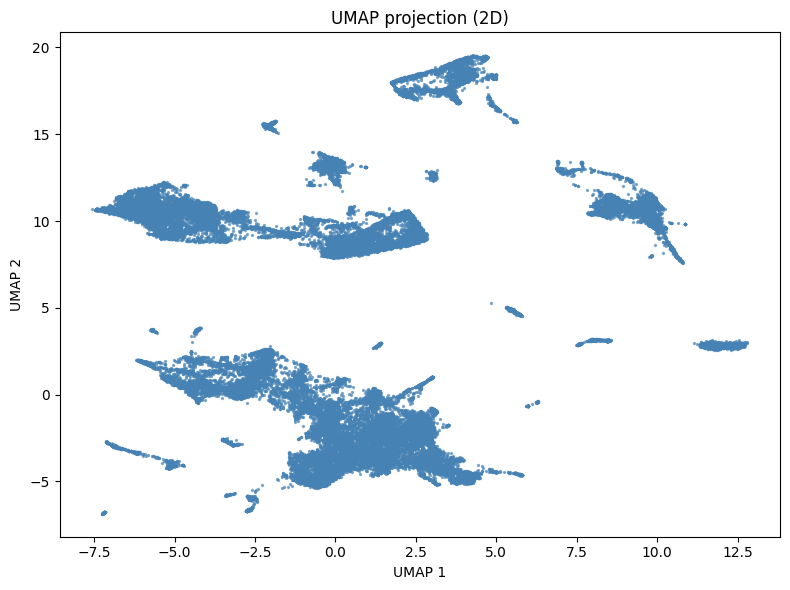

In [18]:
import matplotlib.pyplot as plt

# Assume X_umap is your 2D UMAP result: shape (n_samples, 2)
# Example:
# X_umap = reducer.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=2,        # point size
    alpha=0.6,  # transparency
    c='steelblue'  # color (optional)
)
plt.title("UMAP projection (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

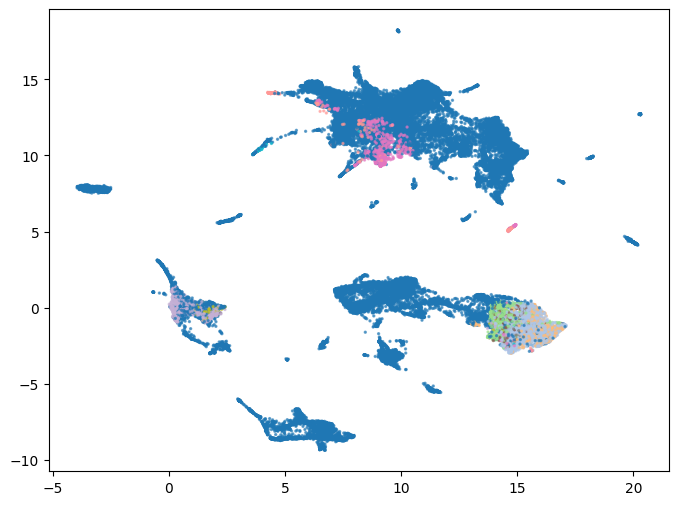

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Suppose you have:
# adata: AnnData object
# X_umap: np.array of shape (n_cells, 2)
# adata.obs["column"]: categorical values (e.g. cell types)

labels = adata.obs["iPS_Label"].astype(str).values
encoded_labels, unique_labels = pd.factorize(labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=encoded_labels,
    cmap="tab20",
    s=2,
    alpha=0.6,
    rasterized=True
)

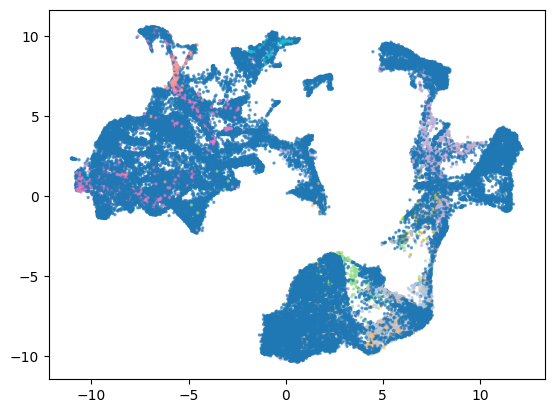

In [12]:
scatter = plt.scatter(
    adata.obsm["X_umap"][:, 0],
    adata.obsm["X_umap"][:, 1],
    c=encoded_labels,
    cmap="tab20",
    s=2,
    alpha=0.6,
    rasterized=True
)

## SCANPY UMAP

In [3]:
import scanpy as sc

In [26]:
adata = ad.read_h5ad(h5ad_file, backed="r")

In [6]:
adata = ad.read_h5ad(h5ad_file)

In [6]:
sc.pp.normalize_total(adata)

In [7]:
sc.pp.log1p(adata)

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [9]:
sc.tl.pca(adata)

In [18]:
adata

AnnData object with n_obs × n_vars = 1034819 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'ata

In [32]:
adata.var[adata.var["gene_name"] == "DRD1"]

,gene_id,gene_name,feature,chromosome,start,stop,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,mt,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,ensembl_id
DRD1,ENSG00000184845,DRD1,Gene Expression,chr5,175444181,175444182,258909,0.388462,0.328197,84.617181,653823,13.390593,False,False,3104.5,0.473465,1.498016,1.472169,8,ENSG00000184845


In [11]:
sc.pp.neighbors(adata)

In [16]:
sc.tl.umap(adata)

In [23]:
np.save("BG/Human_umap.npy", adata.obsm["X_umap"])

In [18]:
adata.obs.to_csv("BG/Human_obs.tsv", sep="\t")

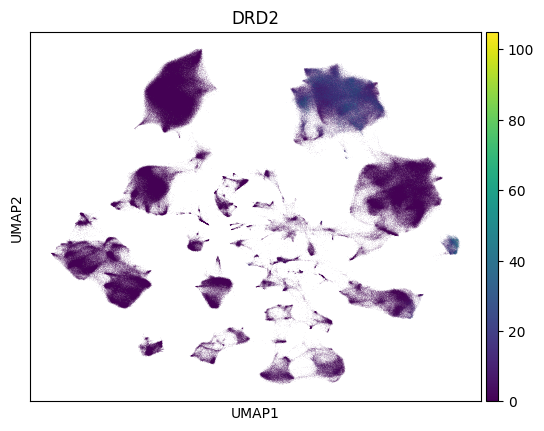

In [8]:
sc.pl.umap(adata, color="DRD2")

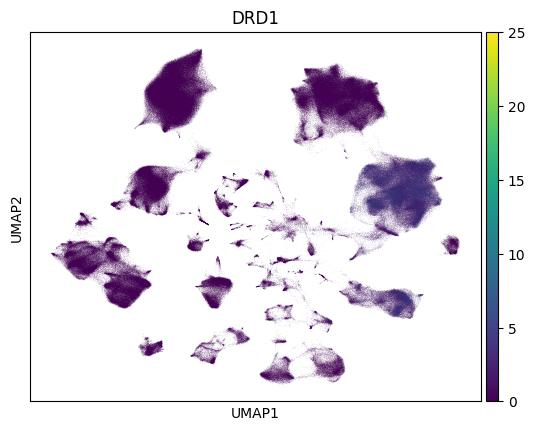

In [9]:
sc.pl.umap(adata, color="DRD1")

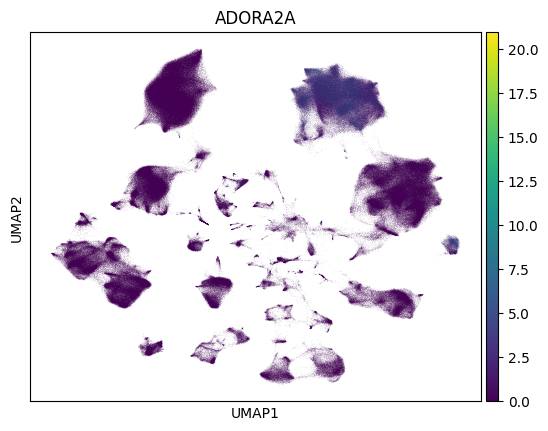

In [16]:
sc.pl.umap(adata, color=["ADORA2A"])

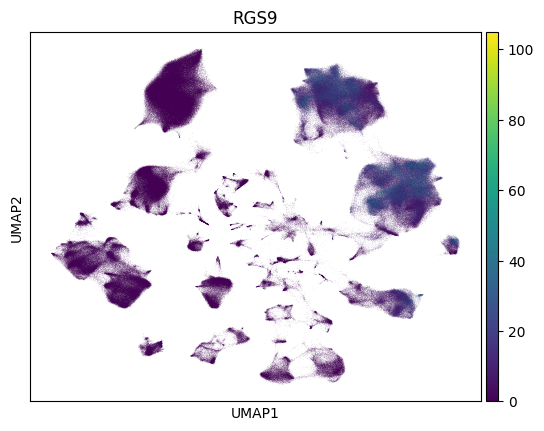

In [17]:
sc.pl.umap(adata, color=["RGS9"])